<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/10_Function_Transformer/Practice_Function_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Function Transform
1. log transform   (right skewed data)
2. Reciprocal transform
3. square(x**2) transform  (left skewed data)
4. Square root (sqrt(2)) transform

In [4]:
import pandas as pd
import numpy as np

import scipy.stats as stats  # Q-Q plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score  # cross validation

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
df = sns.load_dataset('titanic')
df = df.iloc[:,[0,3,6]]
df

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [6]:
df.isnull().sum()

,0
survived,0
age,177
fare,0


In [7]:
# df['age'].fillna(df['age'].median(), inplace=True) # don't write code like this

In [8]:
df.fillna({'age': df['age'].median()}, inplace=True)
df

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


In [9]:
df.isnull().sum()

,0
survived,0
age,0
fare,0


In [10]:
x=df.drop(columns='survived')
x

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,28.0,23.4500
889,26.0,30.0000


In [11]:
y=df.drop(columns=['age', 'fare'])
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [12]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
X_train.head()

,age,fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


/tmp/ipykernel_1389/2691399175.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['age'])


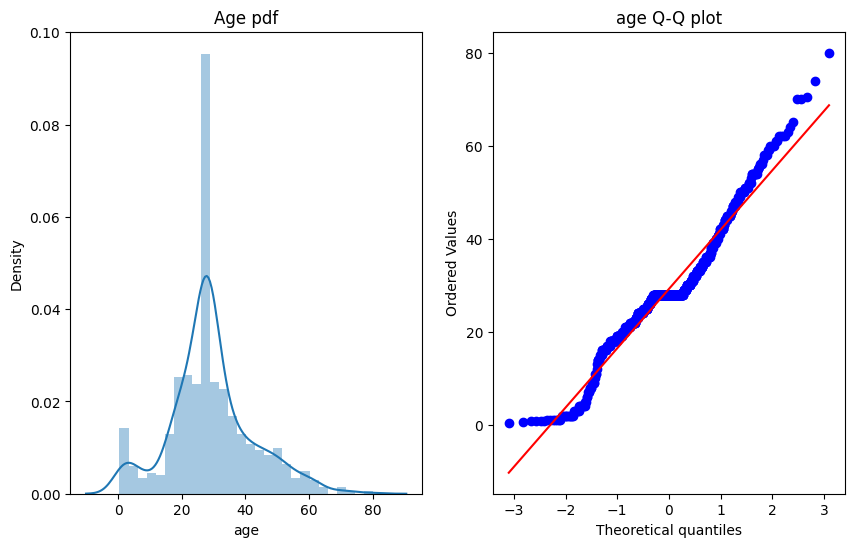

In [14]:
plt.figure(figsize=(10,6))
plt.subplot(121)
sns.distplot(X_train['age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['age'], dist='norm', plot=plt)
plt.title('age Q-Q plot')
plt.show()

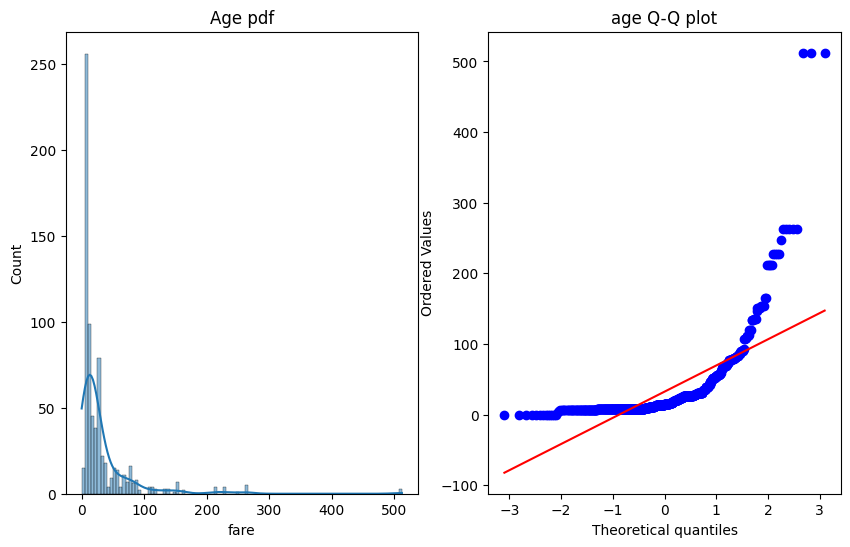

In [15]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(X_train['fare'], kde=True)
plt.title('Age pdf')

plt.subplot(1,2,2)
stats.probplot(X_train['fare'], dist='norm', plot=plt)
plt.title('age Q-Q plot')
plt.show()

In [16]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [17]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


DecisionTreeClassifier()

In [18]:
y_pred = clf.predict(X_test)
y_pred1 = clf.predict(X_test)

In [19]:
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6480446927374302


In [20]:
trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)


In [21]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf.predict(X_test_transformed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [22]:
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

Accuracy LR 0.6759776536312849
Accuracy DT 0.6759776536312849


In [23]:
# cross varify

X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

LR 0.678027465667915
DT 0.6632958801498127


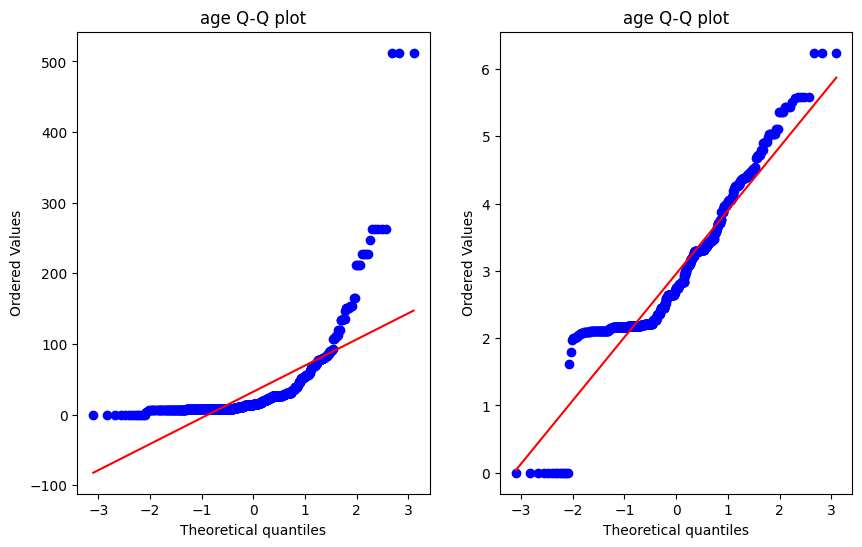

In [24]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
stats.probplot(X_train['fare'], dist='norm', plot=plt)
plt.title('age Q-Q plot')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['fare'], dist='norm', plot=plt)
plt.title('age Q-Q plot')

plt.show()

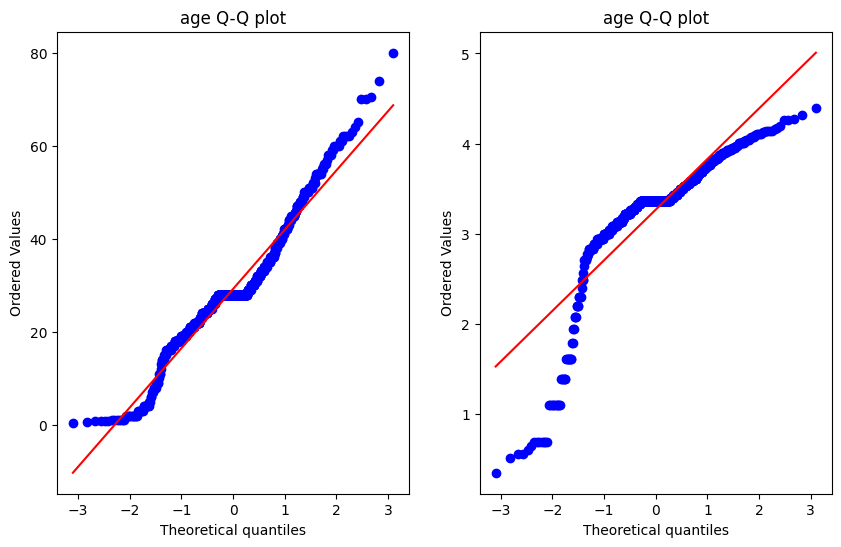

In [25]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
stats.probplot(X_train['age'], dist='norm', plot=plt)
plt.title('age Q-Q plot')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['age'], dist='norm', plot=plt)
plt.title('age Q-Q plot')

plt.show()

In [26]:
# so not apply in age

trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred1 = clf.predict(X_test_transformed2)
print("Accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))


Accuracy LR 0.6759776536312849
Accuracy DT 0.6759776536312849


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [27]:
# cross varify

X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

LR 0.6690137328339576
DT 0.6644194756554307


In [36]:
def apply_transform(transform):
  x = df.iloc[:,1:3]
  y = df.iloc[:,0]

  trf = ColumnTransformer([('log', FunctionTransformer(transform), ['fare'])], remainder='passthrough')

  X_trans = trf.fit_transform(x)

  clf = LogisticRegression()

  print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring = 'accuracy', cv=10)))

  plt.figure(figsize=(14,4))

  plt.subplot(1,2,1)
  stats.probplot(x['fare'], dist='norm', plot=plt)
  plt.title('Fare Before Transform')

  plt.subplot(1,2,2)
  stats.probplot(X_trans[:,0], dist='norm', plot=plt)
  plt.title('Fare After Transform')

  plt.show()

Accuracy 0.6420099875156055


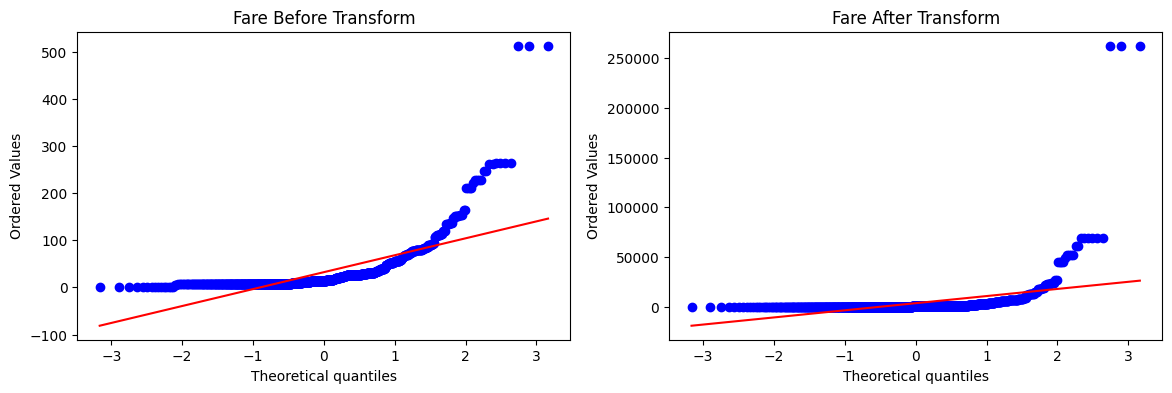

In [38]:
apply_transform(lambda x:x**2)

Accuracy 0.6577777777777778


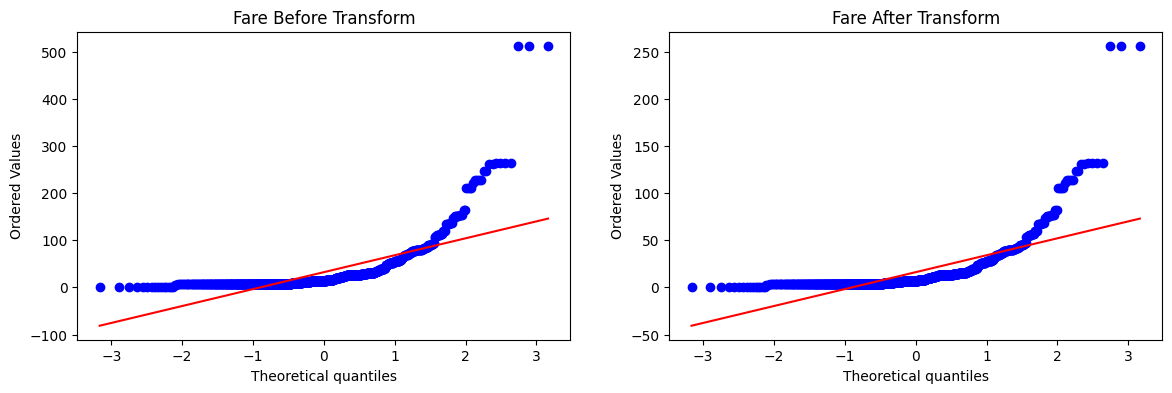

In [39]:
apply_transform(lambda x:x**1/2)

Accuracy 0.6577777777777778


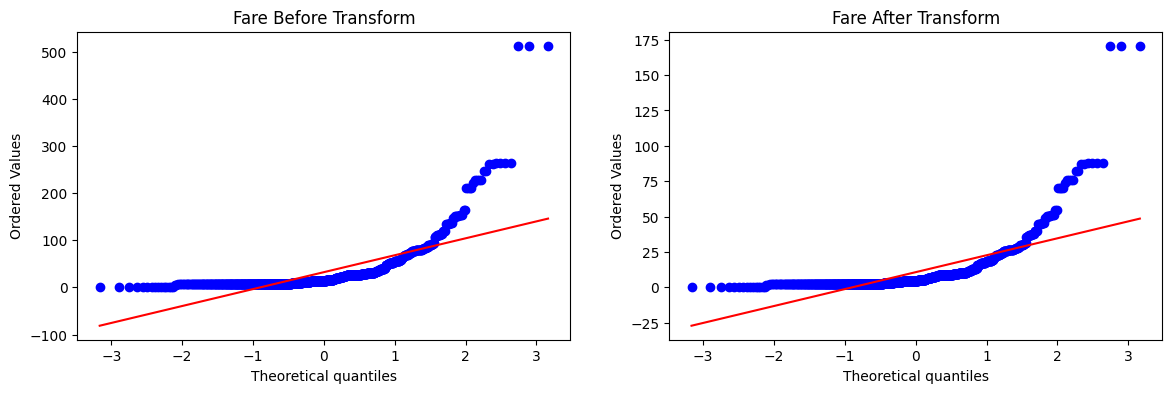

In [41]:
apply_transform(lambda x:x**1/3)

Accuracy 0.61729088639201


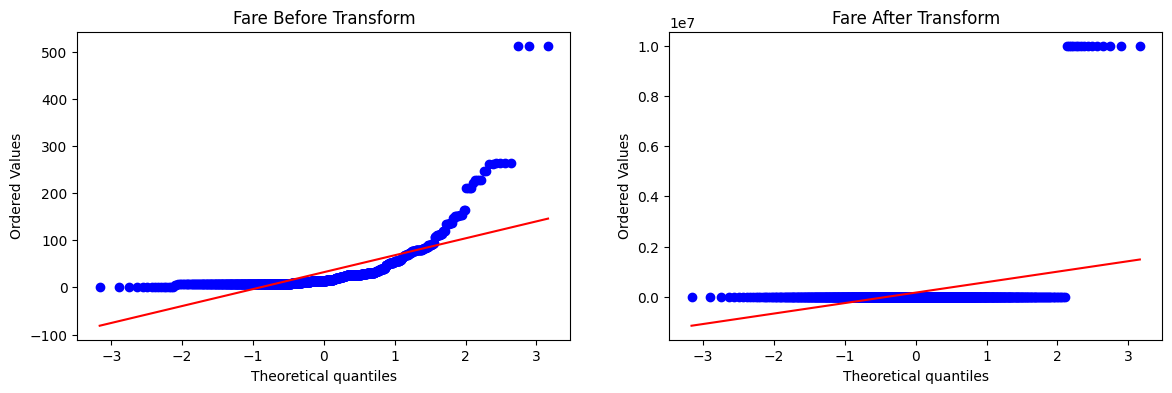

In [44]:
apply_transform(lambda x: 1/(x+0.0000001))

Accuracy 0.6206367041198503


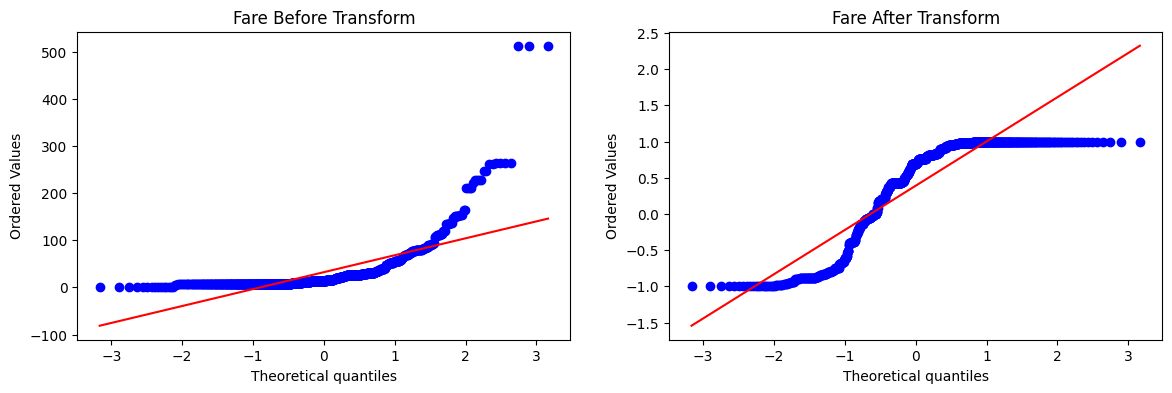

In [45]:
apply_transform(np.sin)

# `random_state` in `train_test_split()` - Notes

## Syntax

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

---

## What is `random_state`?

`random_state` controls the randomness of data shuffling before splitting the dataset.

It ensures that the **same rows** are selected for the training and testing sets every time the code runs.

---

## Important Difference

* `test_size` → Decides **how many rows** go to the test set.
* `random_state` → Decides **which specific rows** go to the test set.

---

## Example

Suppose the dataset has 10 rows:

```text
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
```

### Using `test_size=0.2`

* Training set = 8 rows
* Test set = 2 rows

The number of rows remains the same every time.

---

## Without `random_state`

Run 1:

```text
Train: [1, 2, 3, 4, 5, 7, 8, 10]
Test : [6, 9]
```

Run 2:

```text
Train: [1, 2, 4, 5, 6, 7, 8, 9]
Test : [3, 10]
```

The selected rows change every time.

---

## With `random_state=42`

Run 1:

```text
Train: [1, 2, 3, 4, 5, 7, 8, 10]
Test : [6, 9]
```

Run 2:

```text
Train: [1, 2, 3, 4, 5, 7, 8, 10]
Test : [6, 9]
```

The selected rows remain the same every time.

---

## Why Use `random_state`?

* Makes experiments reproducible
* Helps compare different models fairly
* Ensures others can reproduce your results
* Makes debugging easier

---

## Why is `42` commonly used?

`42` has no special meaning in machine learning.

Any integer can be used:

```python
random_state=0
random_state=1
random_state=42
random_state=100
```

The value `42` became popular because of the book:

**"The Hitchhiker's Guide to the Galaxy"**

where 42 is called:

> "The answer to life, the universe, and everything."

---

## Best Practice

During learning and experiments:

```python
random_state=42
```

For production systems:

* Try multiple random states
* Use cross-validation

---

## Key Point to Remember

```text
test_size → How many rows?

random_state → Which rows?
```
